In [17]:
%pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


In [4]:
%pip install kagglehub
import kagglehub
import os
# Download latest version
current_dir = os.getcwd()
os.environ["KAGGLEHUB_CACHE"] = current_dir
path = kagglehub.dataset_download("datafiniti/consumer-reviews-of-amazon-products")

print("Path to dataset files:", path)

Note: you may need to restart the kernel to use updated packages.


100%|██████████| 16.3M/16.3M [00:01<00:00, 14.7MB/s]

Extracting files...


Path to dataset files: c:\Ironhack\W6\ReviewSense\datasets\datafiniti\consumer-reviews-of-amazon-products\versions\5


In [34]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer

data = pd.read_csv("C:/Ironhack/W6/ReviewSense/datasets/datafiniti/consumer-reviews-of-amazon-products/versions/5/Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products.csv")


In [19]:
print(data.shape)
# data.fillna("",inplace=True)
print(data.head())
print(data.columns)


(5000, 24)
Index(['id', 'dateAdded', 'dateUpdated', 'name', 'asins', 'brand',
       'categories', 'primaryCategories', 'imageURLs', 'keys', 'manufacturer',
       'manufacturerNumber', 'reviews.date', 'reviews.dateAdded',
       'reviews.dateSeen', 'reviews.doRecommend', 'reviews.id',
       'reviews.numHelpful', 'reviews.rating', 'reviews.sourceURLs',
       'reviews.text', 'reviews.title', 'reviews.username', 'sourceURLs'],
      dtype='object')
                     id                                               name  \
0  AVqVGZNvQMlgsOJE6eUY  Amazon Kindle E-Reader 6" Wifi (8th Generation...   
1  AVqVGZNvQMlgsOJE6eUY  Amazon Kindle E-Reader 6" Wifi (8th Generation...   
2  AVqVGZNvQMlgsOJE6eUY  Amazon Kindle E-Reader 6" Wifi (8th Generation...   
3  AVqVGZNvQMlgsOJE6eUY  Amazon Kindle E-Reader 6" Wifi (8th Generation...   
4  AVqVGZNvQMlgsOJE6eUY  Amazon Kindle E-Reader 6" Wifi (8th Generation...   

    brand                                         categories  \
0  Amazon  Com

In [37]:
# the column names shows we can remove some columns that are not relevant to our proj

#PREPOC 1
data.drop(columns=['dateAdded', 'dateUpdated', 'asins', 'manufacturerNumber', 'reviews.date', 'reviews.dateAdded',
       'reviews.dateSeen','reviews.id', 'reviews.username'], inplace=True)
print(data.head())
print(data.columns)

                     id                                               name  \
0  AVqVGZNvQMlgsOJE6eUY  Amazon Kindle E-Reader 6" Wifi (8th Generation...   
1  AVqVGZNvQMlgsOJE6eUY  Amazon Kindle E-Reader 6" Wifi (8th Generation...   
2  AVqVGZNvQMlgsOJE6eUY  Amazon Kindle E-Reader 6" Wifi (8th Generation...   
3  AVqVGZNvQMlgsOJE6eUY  Amazon Kindle E-Reader 6" Wifi (8th Generation...   
4  AVqVGZNvQMlgsOJE6eUY  Amazon Kindle E-Reader 6" Wifi (8th Generation...   

    brand                                         categories  \
0  Amazon  Computers,Electronics Features,Tablets,Electro...   
1  Amazon  Computers,Electronics Features,Tablets,Electro...   
2  Amazon  Computers,Electronics Features,Tablets,Electro...   
3  Amazon  Computers,Electronics Features,Tablets,Electro...   
4  Amazon  Computers,Electronics Features,Tablets,Electro...   

  primaryCategories                                          imageURLs  \
0       Electronics  https://pisces.bbystatic.com/image2/BestBuy_US...  

In [39]:
import seaborn as sns

#check for missing values, since we have only a few rows with missing values, we can drop them
#PREPOC 2

missing_counts = data.isna().sum()
print(missing_counts)
data = data.dropna() 
missing_counts = data.isna().sum()
print(missing_counts)

id                      0
name                    0
brand                   0
categories              0
primaryCategories       0
imageURLs               0
keys                    0
manufacturer            0
reviews.doRecommend     0
reviews.numHelpful      0
reviews.rating          0
reviews.sourceURLs      0
reviews.text            0
reviews.title          13
sourceURLs              0
dtype: int64
id                     0
name                   0
brand                  0
categories             0
primaryCategories      0
imageURLs              0
keys                   0
manufacturer           0
reviews.doRecommend    0
reviews.numHelpful     0
reviews.rating         0
reviews.sourceURLs     0
reviews.text           0
reviews.title          0
sourceURLs             0
dtype: int64


<bound method NDFrame.head of                         id                                               name  \
0     AVqVGZNvQMlgsOJE6eUY  Amazon Kindle E-Reader 6" Wifi (8th Generation...   
1     AVqVGZNvQMlgsOJE6eUY  Amazon Kindle E-Reader 6" Wifi (8th Generation...   
2     AVqVGZNvQMlgsOJE6eUY  Amazon Kindle E-Reader 6" Wifi (8th Generation...   
3     AVqVGZNvQMlgsOJE6eUY  Amazon Kindle E-Reader 6" Wifi (8th Generation...   
4     AVqVGZNvQMlgsOJE6eUY  Amazon Kindle E-Reader 6" Wifi (8th Generation...   
...                    ...                                                ...   
4995  AVqkIdZiv8e3D1O-leaJ  Fire Tablet with Alexa, 7" Display, 16 GB, Mag...   
4996  AVqkIdZiv8e3D1O-leaJ  Fire Tablet with Alexa, 7" Display, 16 GB, Mag...   
4997  AVqkIdZiv8e3D1O-leaJ  Fire Tablet with Alexa, 7" Display, 16 GB, Mag...   
4998  AVqkIdZiv8e3D1O-leaJ  Fire Tablet with Alexa, 7" Display, 16 GB, Mag...   
4999  AVqkIdZiv8e3D1O-leaJ  Fire Tablet with Alexa, 7" Display, 16 GB, Mag...  

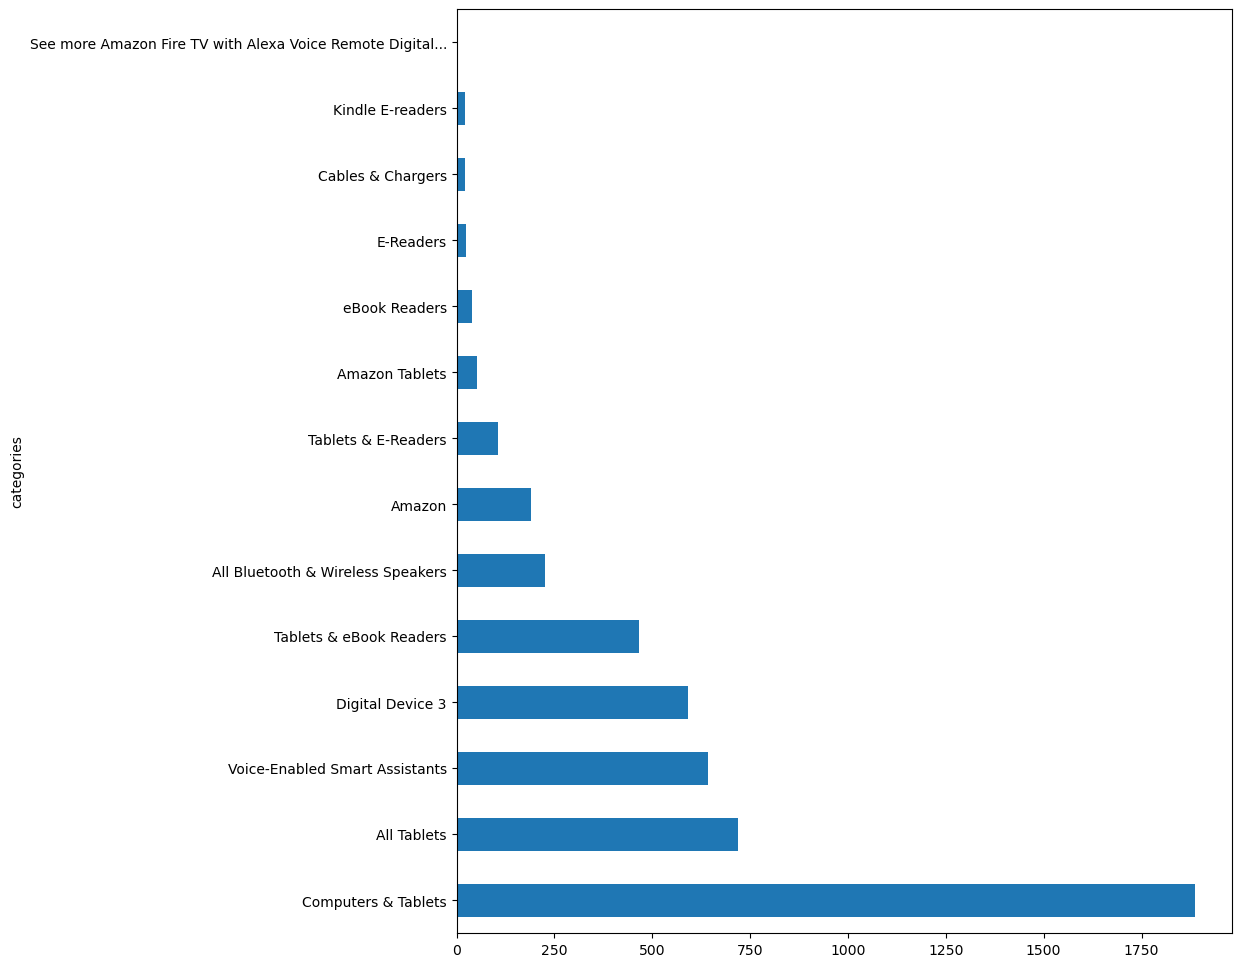

In [44]:
clean_categories = data['categories'].str.split(',').str[-1].str.strip()
clean_categories.value_counts()[:40].plot(kind='barh', figsize=(10,12))
print(data.head)


In [47]:
# # Plotting the top 40 cleaned categories
# clean_categories.value_counts()[:40].plot(kind='bar', figsize=(12, 6))

# # Apply log scale to the Y-axis
# plt.yscale('log')

# plt.title('Category Distribution (Log Scale)')
# plt.ylabel('Count (Log Scale)')
# plt.show()


In [48]:
top5_pct = data['categories'].value_counts(normalize=True)[:5].sum() * 100
print(f"The top 5 categories make up {top5_pct:.2f}% of the data.")

# since the top 5 categories make up 60% of the data we can conclude the categories are imabalanced

The top 5 categories make up 61.30% of the data.


rating_sentiment
pos    0.937036
neu    0.039503
neg    0.023461
Name: proportion, dtype: float64


<Axes: xlabel='rating_sentiment'>

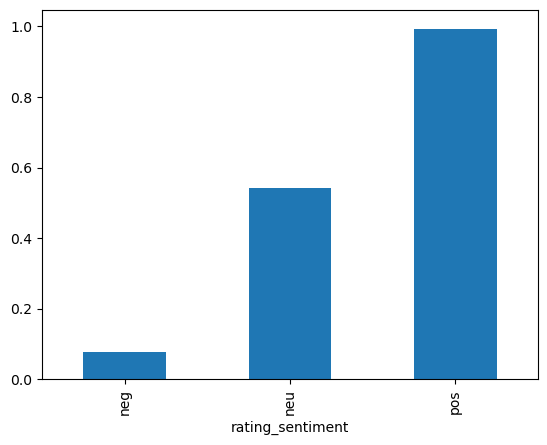

In [61]:
#now lets check the distribution of the ratings
# sns.countplot(x='reviews.rating', data=data, palette='viridis')
# plt.title('Ratings Distribution')

# the ratings are also imbalanced with most of the ratings being 5 stars. Needs to be addressed while modelling
# since we are trying do sentiment analysis of the reviews, we can create a new column called sentiment which will be positive for ratings 4 and 5, negative for 1 and 2, and neutral for 3.

ratings_map = {5:'pos',4:'pos',3:'neu',2:'neg',1:'neg'}
data['rating_sentiment'] = data['reviews.rating'].map(ratings_map)
print(data['rating_sentiment'].value_counts(normalize=True))
data.groupby('reviews.rating')['reviews.doRecommend'].mean().plot(kind='bar')
data.groupby('rating_sentiment')['reviews.doRecommend'].mean().plot(kind='bar')


In [89]:
print((data['rating_sentiment'] == 'pos').sum())
print((data['rating_sentiment'] == 'neg').sum())
print((data['rating_sentiment'] == 'neu').sum())

4673
117
197


0.16041708441949068


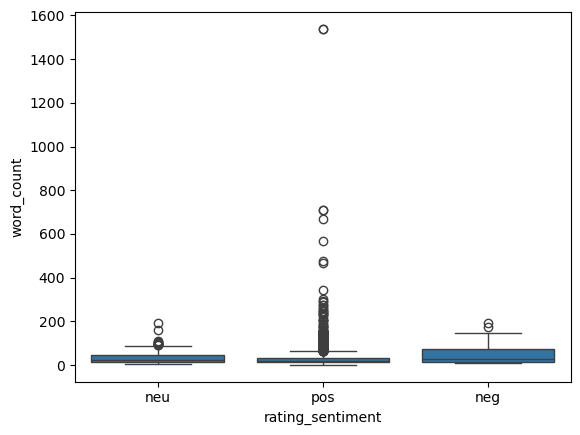

In [71]:
data['word_count'] = data['reviews.text'].str.split().str.len()
sns.boxplot(x='rating_sentiment', y='word_count', data=data)
print((data['word_count'] > 400).mean() * 100)

0.04015257980325236


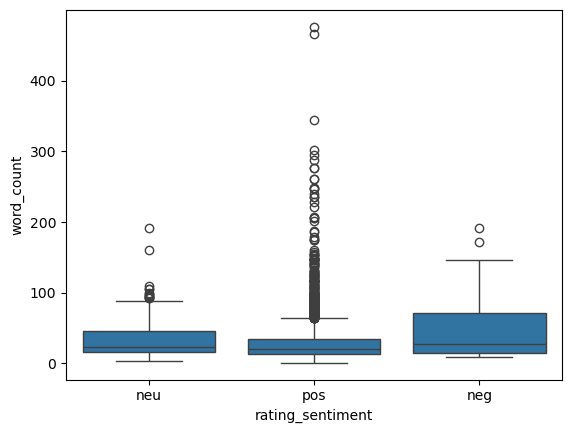

In [72]:
df_filtered = data[data['word_count'] <= 500]
# data['word_count'] = data['reviews.text'].str.split().str.len()
sns.boxplot(x='rating_sentiment', y='word_count', data=df_filtered)
print((df_filtered['word_count'] > 400).mean() * 100)

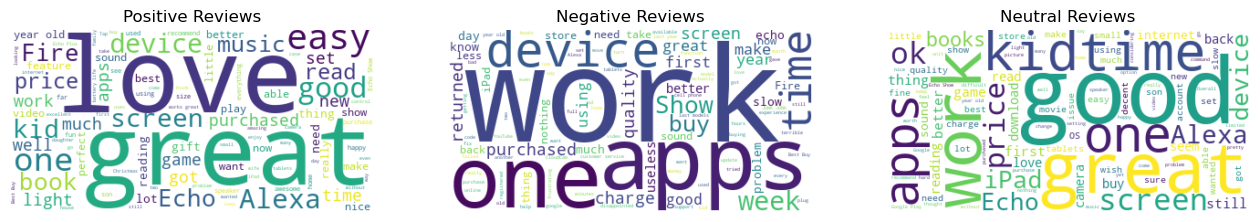

In [85]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt


STOPWORDS.update(["product", "item", "Amazon", "Kindle", "use", "app", "will", "tablet", "bought" ])
# 1. Create text blobs for each sentiment
pos_text = " ".join(data[data['rating_sentiment'] == 'pos']['reviews.text'])
neg_text = " ".join(data[data['rating_sentiment'] == 'neg']['reviews.text'])
neu_text = " ".join(data[data['rating_sentiment'] == 'neu']['reviews.text'])

# 2. Generate and plot
wc = WordCloud(stopwords=STOPWORDS, background_color='white', max_words=100)

plt.figure(figsize=(16, 8))

# Positive Cloud
plt.subplot(1, 3, 1)
plt.imshow(wc.generate(pos_text), interpolation='bilinear')
plt.title('Positive Reviews')
plt.axis('off')

# Negative Cloud
plt.subplot(1, 3, 2)
plt.imshow(wc.generate(neg_text), interpolation='bilinear')
plt.title('Negative Reviews')
plt.axis('off')

# Neutral Cloud
plt.subplot(1, 3, 3)
plt.imshow(wc.generate(neu_text), interpolation='bilinear')
plt.title('Neutral Reviews')
plt.axis('off')


plt.show()
